# Stage 05 — Regression (RQ1)

**Owner:** Sandesh Shahi (Analysis Lead)

**Research question.** *To what extent can industry sector, employer size, and policy adoption predict the proportion of women in management positions?*

**Models:**

1. **Simple Linear Regression (baseline)** — one predictor (the feature most strongly correlated with the target). Gives us a benchmark we can beat with more information.
2. **Multiple Linear Regression (full model)** — all engineered predictors (ordinal employer size + policy flags + one-hot ANZSIC divisions).

Response variable is continuous in [0, 1], so linear regression quantifies individual + combined predictor effects and supports transparent coefficient interpretation.

**Evaluation.** 80/20 train/test split (same split for both models). Metrics: MAE, RMSE, R², Adjusted R² (justified in `src/evaluation.py`).

**Assumption checks.** Linearity & homoscedasticity (residuals vs fitted), normality of residuals (Q-Q plot). No-multicollinearity check was done in notebook 04 via VIF.

**Inputs.** Checkpoints from notebook 03 (feature engineering): `X`, `y_reg`, `feature_names`.

**Outputs.**
- `data/processed/checkpoints/05_ols_simple.pkl`, `05_ols_multiple.pkl`
- `data/processed/checkpoints/05_reg_metrics.json` (both models)
- `outputs/figures/rq1_*.png` (residuals, Q-Q, coefficients, predicted-vs-actual)

## 1. Setup and load checkpoints

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
from IPython.display import Image, display

from src import config, regression, evaluation, visualisation
from src.utils import save_checkpoint

pd.set_option("display.max_columns", 30)

def _load(name):
    p = config.CHECKPOINT_DIR / name
    return pd.read_parquet(p) if p.exists() else pd.read_csv(p.with_suffix('.csv'))

X = _load("03_X.parquet")
y_reg = _load("03_y_reg.parquet").iloc[:, 0]
feature_names = json.load(open(config.CHECKPOINT_DIR / "03_feature_names.json"))
print("X:", X.shape, "| y_reg:", y_reg.shape)

X: (7971, 24) | y_reg: (7971,)


## 2. Pick the single strongest predictor for the Simple LR baseline

Week 1 introduced Simple Linear Regression (one predictor). We pick the numeric feature with the highest absolute Pearson correlation with the target — that gives the baseline every chance of being reasonable so the comparison with the full Multiple LR is meaningful.

In [2]:
corrs = X.apply(lambda col: col.corr(y_reg)).abs().sort_values(ascending=False)
best_feature = corrs.index[0]
print("Top 5 features by |correlation with target|:")
print(corrs.head(5).round(3).to_string())
print(f"\nSimple LR baseline predictor: {best_feature}")

Top 5 features by |correlation with target|:
div_Health Care and Social Assistance    0.483
div_Manufacturing                        0.262
div_Construction                         0.257
div_Education and Training               0.203
div_Mining                               0.181

Simple LR baseline predictor: div_Health Care and Social Assistance


## 3. Fit both models on the same 80/20 split

Both models use `src.regression.fit_linear_regression`, which internally sets `random_state = config.RANDOM_SEED`, so the train/test indices are identical — making the head-to-head comparison fair.

In [3]:
X_simple = X[[best_feature]]

simple_res = regression.fit_linear_regression(X_simple, y_reg)
multi_res  = regression.fit_linear_regression(X, y_reg)

print(f"Simple LR  — 1 predictor ({best_feature})")
print(f"  intercept = {simple_res.model.intercept_:.4f}   "
      f"coef = {simple_res.model.coef_[0]:.4f}")
print(f"\nMultiple LR — {X.shape[1]} predictors")
print(f"  intercept = {multi_res.model.intercept_:.4f}")

20:34:52 | INFO    | src.regression | OLS fitted: 6376 train / 1595 test samples, 1 features
20:34:52 | INFO    | src.regression | OLS fitted: 6376 train / 1595 test samples, 24 features
Simple LR  — 1 predictor (div_Health Care and Social Assistance)
  intercept = 0.3661   coef = 0.3417

Multiple LR — 24 predictors
  intercept = 0.4315


## 4. Evaluation metrics (test set)

- **MAE** — average absolute error, robust to outliers, on the same 0–1 scale as the target.
- **RMSE** — penalises large errors more; informative for a bounded target.
- **R²** — share of variance explained.
- **Adjusted R²** — penalises adding predictors, so we don't fool ourselves with a big one-hot block.

Lower MAE/RMSE and higher R²/Adj-R² are better.

In [4]:
m_simple = evaluation.regression_metrics(
    simple_res.y_test.values, simple_res.y_pred_test, n_features=1,
)
m_multi  = evaluation.regression_metrics(
    multi_res.y_test.values, multi_res.y_pred_test, n_features=X.shape[1],
)

comparison = pd.DataFrame({"Simple LR": m_simple, "Multiple LR": m_multi}).round(4)
comparison

,Simple LR,Multiple LR
MAE,0.1782,0.1419
RMSE,0.2188,0.1827
R2,0.2324,0.4647
Adj_R2,0.2319,0.4566


## 5. Assumption diagnostics (Multiple LR)

Residuals vs fitted checks linearity + homoscedasticity; the Q-Q plot checks normality of residuals. We only plot these for the full model since it's the one we'll use in interpretation.

20:34:53 | INFO    | src.regression | Saved regression diagnostic plots.
residuals_vs_fitted


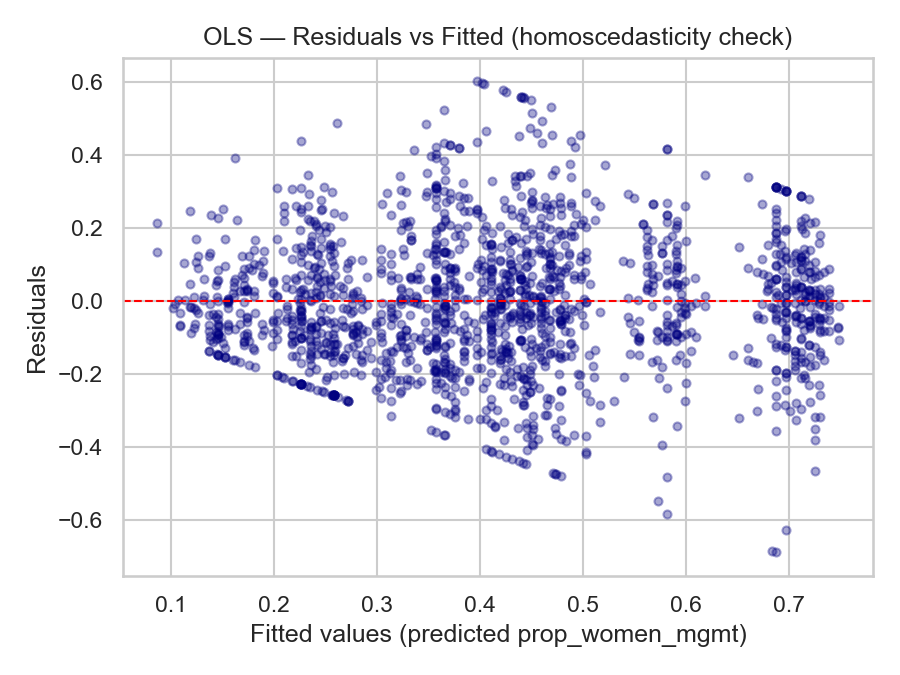

qq_plot


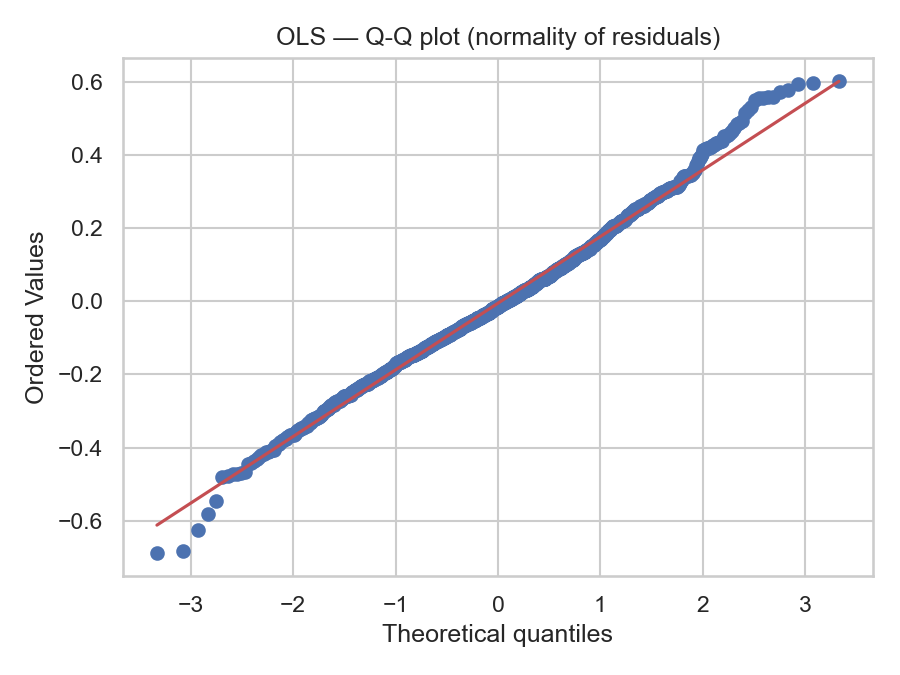

In [5]:
diag_paths = regression.diagnostics(multi_res, prefix="rq1")
for name, p in diag_paths.items():
    print(name)
    display(Image(str(p)))

## 6. Presentation figures (Multiple LR)

Top coefficients table + coefficient bar chart + predicted-vs-actual scatter.

Top 15 predictors (Multiple LR):


,feature,coef
0,div_Construction,-0.3223
1,div_Mining,-0.3155
2,div_Manufacturing,-0.2416
3,"div_Electricity, Gas, Water and Waste Services",-0.2355
4,div_Health Care and Social Assistance,0.2288
5,"div_Agriculture, Forestry and Fishing",-0.2114
6,"div_Transport, Postal and Warehousing",-0.2105
7,div_Public Administration and Safety,-0.1980
8,div_Wholesale Trade,-0.1547
9,"div_Rental, Hiring and Real Estate Services",-0.1295


20:34:53 | INFO    | src.visualisation | Saved rq1_coefficients.png
20:34:53 | INFO    | src.visualisation | Saved rq1_pred_vs_actual.png


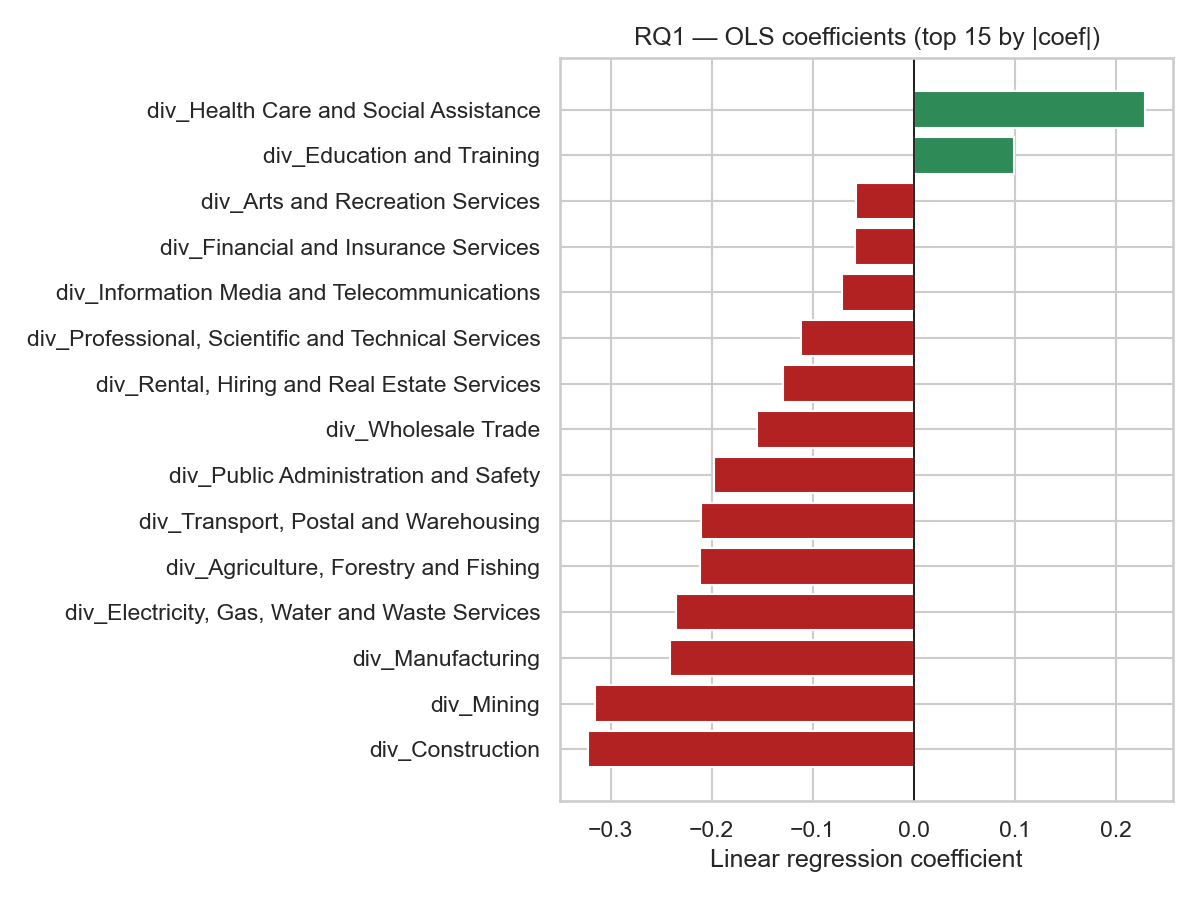

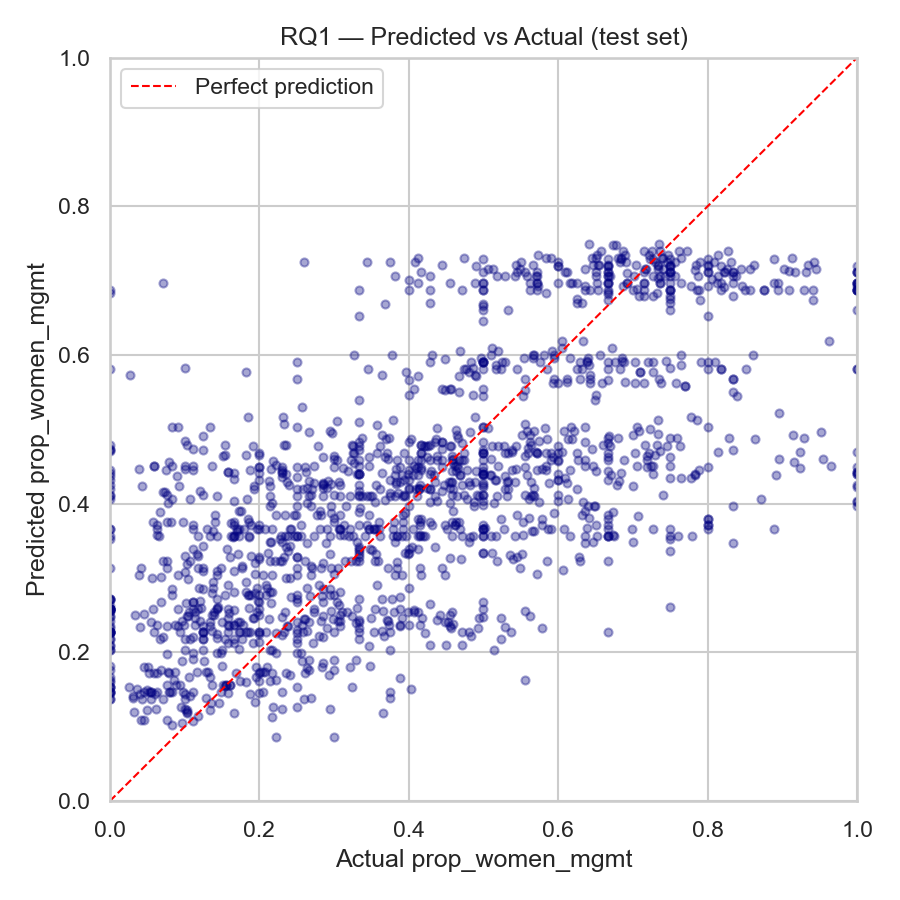

In [6]:
coefs = (
    pd.DataFrame({"feature": feature_names, "coef": multi_res.model.coef_})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)
print("Top 15 predictors (Multiple LR):")
display(coefs.head(15).round(4))

p1 = visualisation.plot_regression_coefficients(multi_res.model, feature_names)
p2 = visualisation.plot_predicted_vs_actual(multi_res.y_test.values, multi_res.y_pred_test)
display(Image(str(p1)))
display(Image(str(p2)))

## 7. Checkpoint — hand off to notebook 07

## Interpretation for the slide deck

- **Simple vs Multiple LR metrics** — the comparison table in section 4 is our headline number. Multiple LR should beat Simple LR on MAE/RMSE/R², and notebook 07 formalises whether that gap is statistically significant (paired k-fold CV t-test).
- **Top coefficients** — features with the largest positive coefficients push predicted women-in-management *up* (likely health/education divisions, some policy flags). Large negatives push it *down* (construction, mining, manufacturing etc.). Talk about the top 3–5 in plain language.
- **Adjusted R²** — tells the audience how much of the variation across ~12k employers our model actually explains.
- **Residual diagnostics** — if residuals-vs-fitted show a curve or funnel, flag it honestly as a model limitation on the limitations slide. A bounded target in [0, 1] can break the normality assumption — we mention this even if Q-Q looks reasonable.

**Next:** `06_classification.ipynb` — RQ2 Naive Bayes on the binary version of the same target.

In [7]:
save_checkpoint(simple_res.model, config.CHECKPOINT_DIR / "05_ols_simple.pkl")
save_checkpoint(multi_res.model,  config.CHECKPOINT_DIR / "05_ols_multiple.pkl")

with open(config.CHECKPOINT_DIR / "05_reg_metrics.json", "w") as f:
    json.dump({
        "simple_lr":   {"predictor": best_feature, **m_simple},
        "multiple_lr": {"n_features": int(X.shape[1]), **m_multi},
    }, f, indent=2)
print("Saved both OLS models + metrics.")

Saved both OLS models + metrics.
